In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Dataset .csv")

In [4]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
# Count restaurants in each price range
price_counts = df["Price range"].value_counts().sort_index()

print("Number of restaurants in each price range:")
print(price_counts)

# Find the most common price range
most_common_range = price_counts.idxmax()
most_common_count = price_counts.max()

print(f"\nMost common price range: {most_common_range}")
print(f"Number of restaurants: {most_common_count}")

Number of restaurants in each price range:
1    4444
2    3113
3    1408
4     586
Name: Price range, dtype: int64

Most common price range: 1
Number of restaurants: 4444


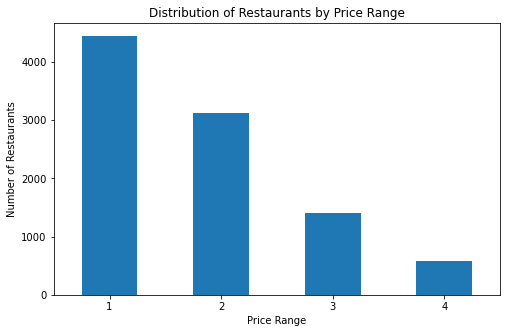

In [6]:
plt.figure(figsize=(8, 5))

price_counts.plot(kind="bar")

plt.title("Distribution of Restaurants by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)

plt.show()

In [7]:
# Calculate average rating for each price range
avg_rating_by_price = (
    df.groupby("Price range")["Aggregate rating"]
    .mean()
)

print("Average Rating by Price Range:")
print(avg_rating_by_price.round(2))

Average Rating by Price Range:
Price range
1    2.00
2    2.94
3    3.68
4    3.82
Name: Aggregate rating, dtype: float64


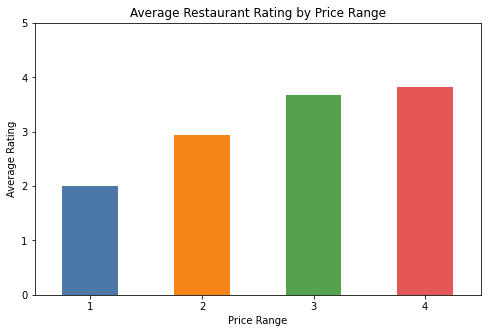

In [8]:
# Define colors for each price range
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

# Plot average rating for each price range
plt.figure(figsize=(8, 5))

avg_rating_by_price.plot(
    kind="bar",
    color=colors
)

plt.title("Average Restaurant Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.ylim(0, 5)

plt.show()

In [9]:
# Find the price range with the highest average rating
highest_range = avg_rating_by_price.idxmax()
highest_rating = avg_rating_by_price.max()

# Find its position in the chart
highest_index = list(avg_rating_by_price.index).index(highest_range)

# Get the corresponding color
highest_color = colors[highest_index]

print(f"Highest average rating: Price Range {highest_range}")
print(f"Average rating: {highest_rating:.2f}")
print(f"Color representing the highest average rating: {highest_color}")

Highest average rating: Price Range 4
Average rating: 3.82
Color representing the highest average rating: #E45756


In [10]:
print("Conclusion:")
print(
    f"Price Range {highest_range} has the highest average restaurant rating "
    f"of {highest_rating:.2f}. It is represented by the color {highest_color}."
)

Conclusion:
Price Range 4 has the highest average restaurant rating of 3.82. It is represented by the color #E45756.
